In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit


In [2]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)

In [3]:
import sklearn
from sklearn.decomposition import PCA

In [4]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [5]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [6]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)):
                t = t
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [7]:
header = "D:/K_sunada/result/CDY168/"

In [8]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_ref']['values'][k:k+num_of_fogi_freq]
        # q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        # q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-249):
                t = t+200
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
                
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

photon freq = 9.35

photon 0

In [9]:
ph0_fo0 = "/2024-10-14/2024-10-14T002400_2c4d656d-75-sym_JPA_ab_fogi_timing"
ph0_fo1 = "/2024-10-14/2024-10-14T014414_6193297f-75-sym_JPA_ab_fogi_timing"
ph0_fo2 = "/2024-10-14/2024-10-14T030437_9c5ec62d-75-sym_JPA_ab_fogi_timing"
ph0_fo3 = "/2024-10-14/2024-10-14T081814_6bc8099a-75-sym_JPA_ab_fogi_timing"

In [10]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d00 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time00 = d00[0][ph_amp]
ph0fo0 = d00[5][ph_amp]

In [11]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d01 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time01 = d01[0][ph_amp]
ph0fo1 = d01[5][ph_amp]

In [12]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d02 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time02 = d02[0][ph_amp]
ph0fo2 = d02[5][ph_amp]

In [13]:
## absorption rate
ph_amp = 0
###############################################
data = ph0_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d03 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time03 = d03[0][ph_amp]
ph0fo3 = d03[5][ph_amp]

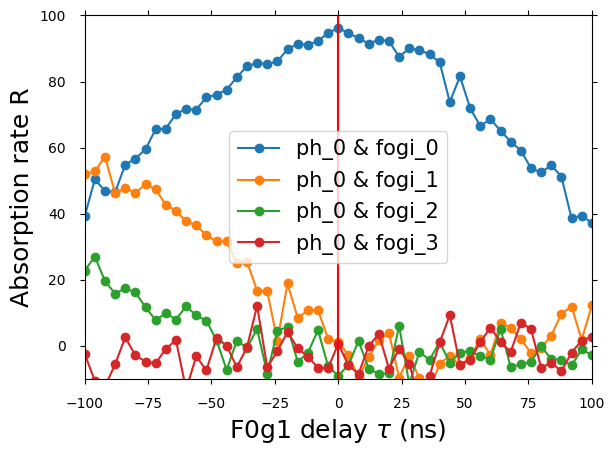

In [14]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o-", label= "ph_0 & fogi_0")
plt.plot(time01, ph0fo1, "o-", label= "ph_0 & fogi_1")
plt.plot(time02, ph0fo2, "o-", label= "ph_0 & fogi_2")
plt.plot(time03, ph0fo3, "o-", label= "ph_0 & fogi_3")
plt.vlines(0, -10, 100, color="r")
plt.legend()
plt.show()

96.22
1.03


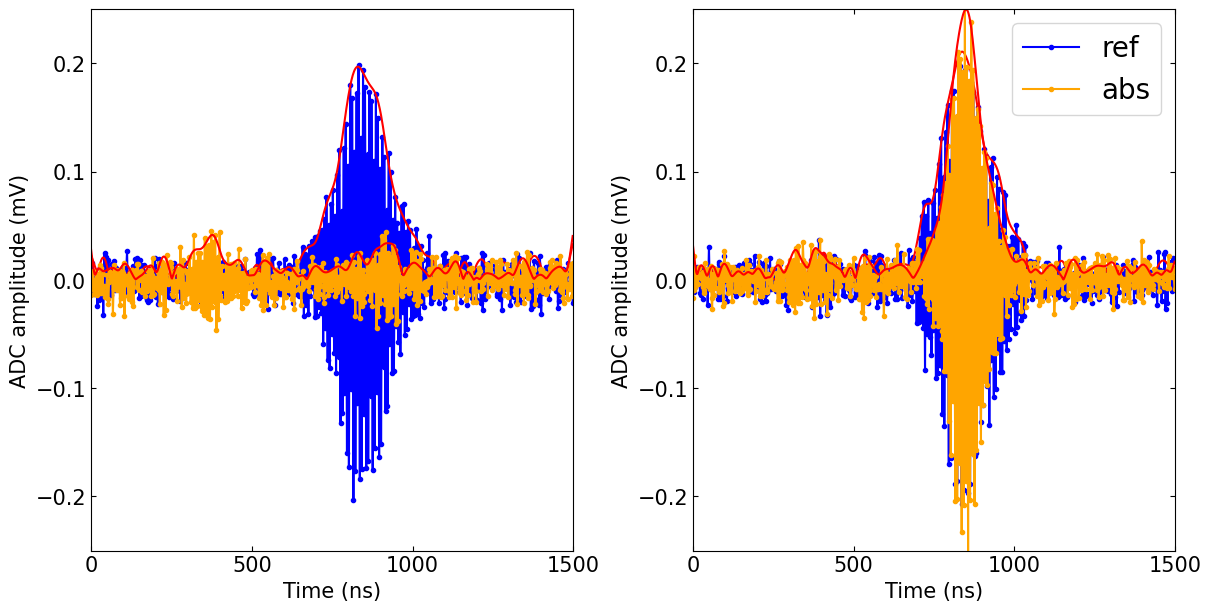

In [15]:
## waveform
ph_amp = 0
fogi_freq = 25

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d00[1][ph_amp][fogi_freq],  (d00[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.25, 0.25)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d01[1][ph_amp][fogi_freq],  (d01[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_ylim(-0.25, 0.25)
ax[1].set_xlim(0, 1500)
plt.legend()
print(np.round(d00[5][ph_amp][fogi_freq], 2))
print(np.round(d01[5][ph_amp][fogi_freq], 2))
plt.show()

-9.11
0.64


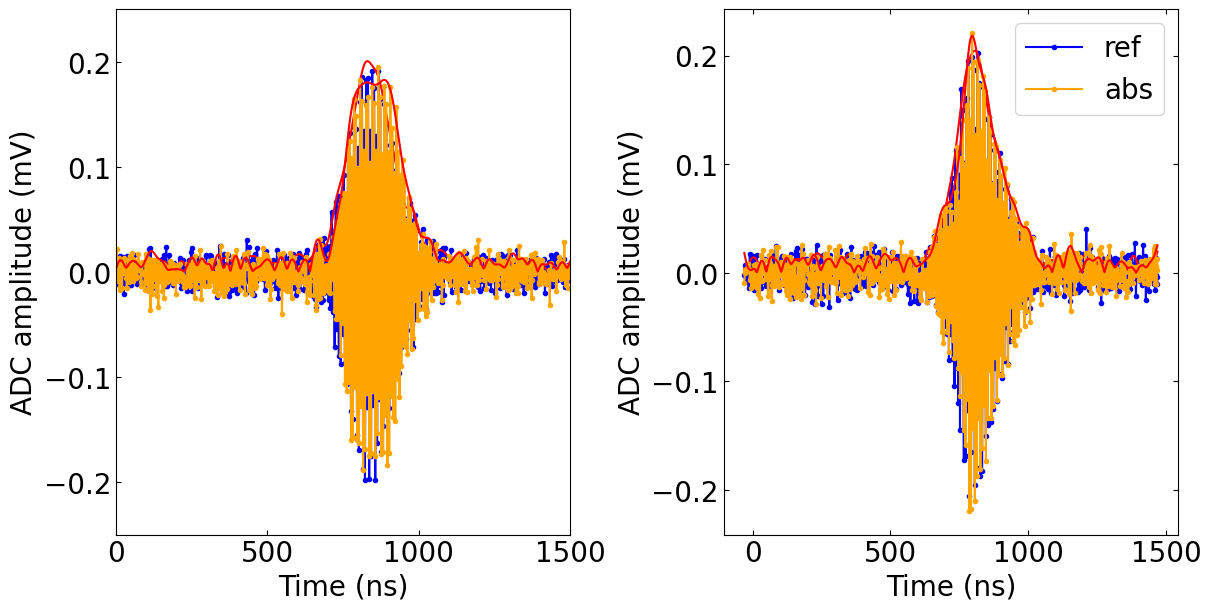

In [16]:
## waveform
ph_amp = 0
fogi_freq = 25

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d02[1][ph_amp][fogi_freq],  (d02[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.25, 0.25)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d03[1][ph_amp][fogi_freq]-30,  (d03[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d03[1][ph_amp][fogi_freq]-30,  (d03[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d03[1][ph_amp][fogi_freq]-30,  (d03[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d03[1][ph_amp][fogi_freq]-30,  (d03[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.25, 0.25)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d02[5][ph_amp][fogi_freq], 2))
print(np.round(d03[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 1

In [17]:
ph1_fo0 = "/2024-10-14/2024-10-14T095739_4f379ac9-75-sym_JPA_ab_fogi_timing"
ph1_fo1 = "2024-10-14/2024-10-14T111703_67272cb3-75-sym_JPA_ab_fogi_timing"
ph1_fo2 = "/2024-10-14/2024-10-14T123643_881c058c-75-sym_JPA_ab_fogi_timing"
ph1_fo3 = "/2024-10-14/2024-10-14T135839_fa6908b4-75-sym_JPA_ab_fogi_timing"

In [18]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d10 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time10 = d10[0][ph_amp]
ph1fo0 = d10[5][ph_amp]

In [19]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d11 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time11 = d11[0][ph_amp]
ph1fo1 = d11[5][ph_amp]

In [20]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d12 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time12 = d12[0][ph_amp]
ph1fo2 = d12[5][ph_amp]

In [21]:
## absorption rate
ph_amp = 0
###############################################
data = ph1_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d13 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time13 = d13[0][ph_amp]
ph1fo3 = d13[5][ph_amp]

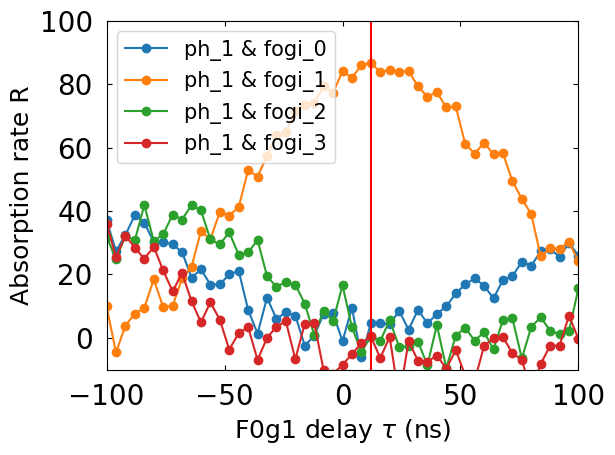

In [22]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time10, ph1fo0, "o-", label= "ph_1 & fogi_0")
plt.plot(time11, ph1fo1, "o-", label= "ph_1 & fogi_1")
plt.plot(time12, ph1fo2, "o-", label= "ph_1 & fogi_2")
plt.plot(time13, ph1fo3, "o-", label= "ph_1 & fogi_3")
plt.vlines(12, -10, 100, color="r")
plt.legend()
plt.show()

4.54
86.85


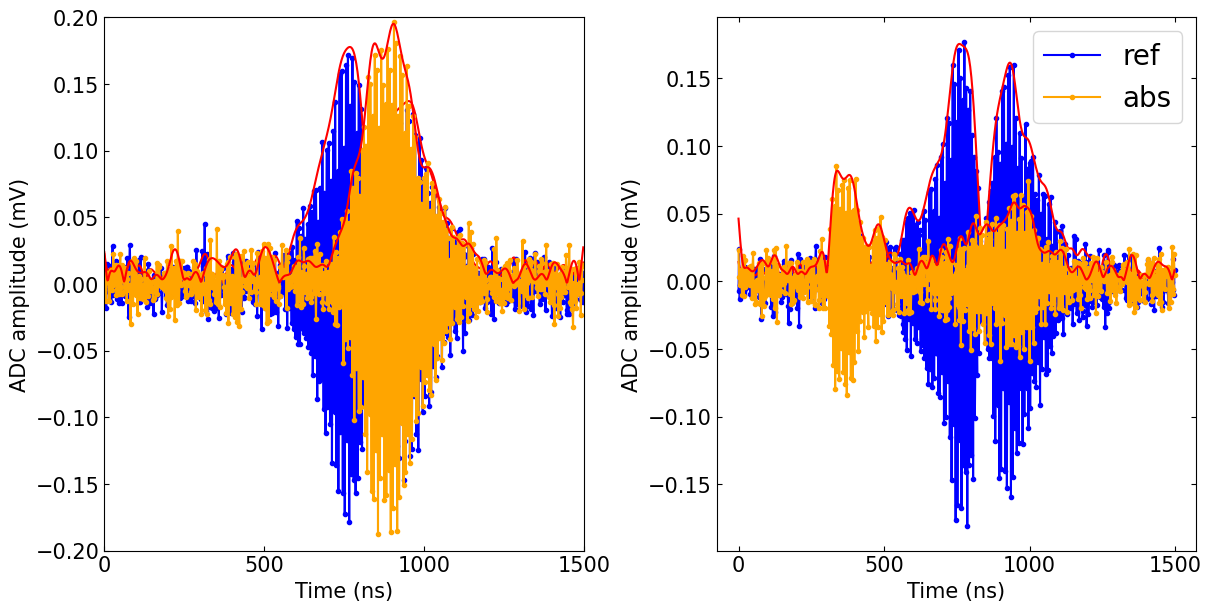

In [23]:
## waveform
ph_amp = 0
fogi_freq = 28

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d10[1][ph_amp][fogi_freq],  (d10[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d11[1][ph_amp][fogi_freq],  (d11[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d10[5][ph_amp][fogi_freq], 2))
print(np.round(d11[5][ph_amp][fogi_freq], 2))
plt.show()

0.37
0.47


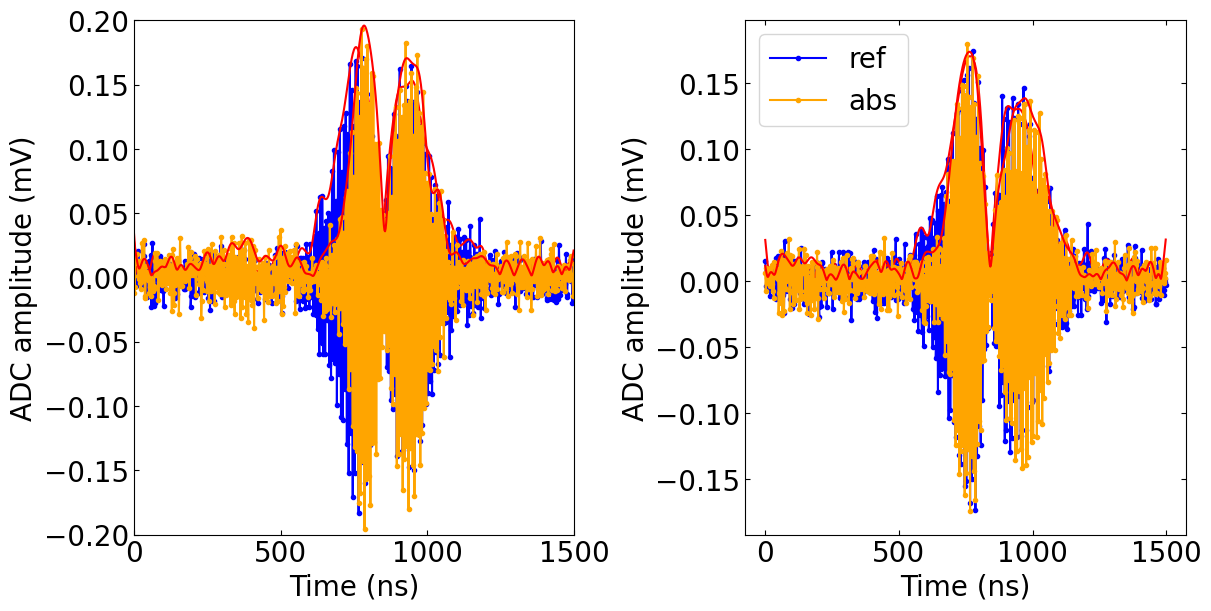

In [25]:
## waveform
ph_amp = 0
fogi_freq = 28

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d12[1][ph_amp][fogi_freq],  (d12[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d13[1][ph_amp][fogi_freq],  (d13[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d12[5][ph_amp][fogi_freq], 2))
print(np.round(d13[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 2

In [27]:
ph2_fo0 = "/2024-10-14/2024-10-14T152211_a5722b72-75-sym_JPA_ab_fogi_timing"
ph2_fo1 = "/2024-10-14/2024-10-14T164342_08b61c18-75-sym_JPA_ab_fogi_timing"
ph2_fo2 = "/2024-10-14/2024-10-14T180606_8b7fba60-75-sym_JPA_ab_fogi_timing"
ph2_fo3 = "/2024-10-14/2024-10-14T192818_072c6c9c-75-sym_JPA_ab_fogi_timing"

In [28]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d20 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time20 = d20[0][ph_amp]
ph2fo0 = d20[5][ph_amp]

In [29]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d21 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time21 = d21[0][ph_amp]
ph2fo1 = d21[5][ph_amp]

In [30]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d22 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time22 = d22[0][ph_amp]
ph2fo2 = d22[5][ph_amp]

In [31]:
## absorption rate
ph_amp = 0
###############################################
data = ph2_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d23 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time23 = d23[0][ph_amp]
ph2fo3 = d23[5][ph_amp]

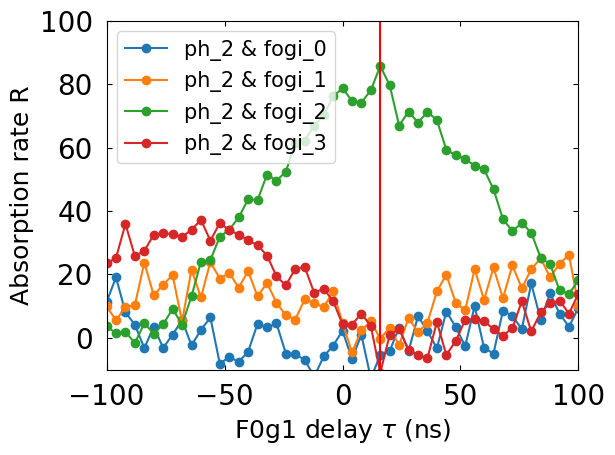

In [32]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time20, ph2fo0, "o-", label= "ph_2 & fogi_0")
plt.plot(time21, ph2fo1, "o-", label= "ph_2 & fogi_1")
plt.plot(time22, ph2fo2, "o-", label= "ph_2 & fogi_2")
plt.plot(time23, ph2fo3, "o-", label= "ph_2 & fogi_3")
plt.vlines(16, -10, 100, color="r")
plt.legend()
plt.show()

-5.4
-0.29


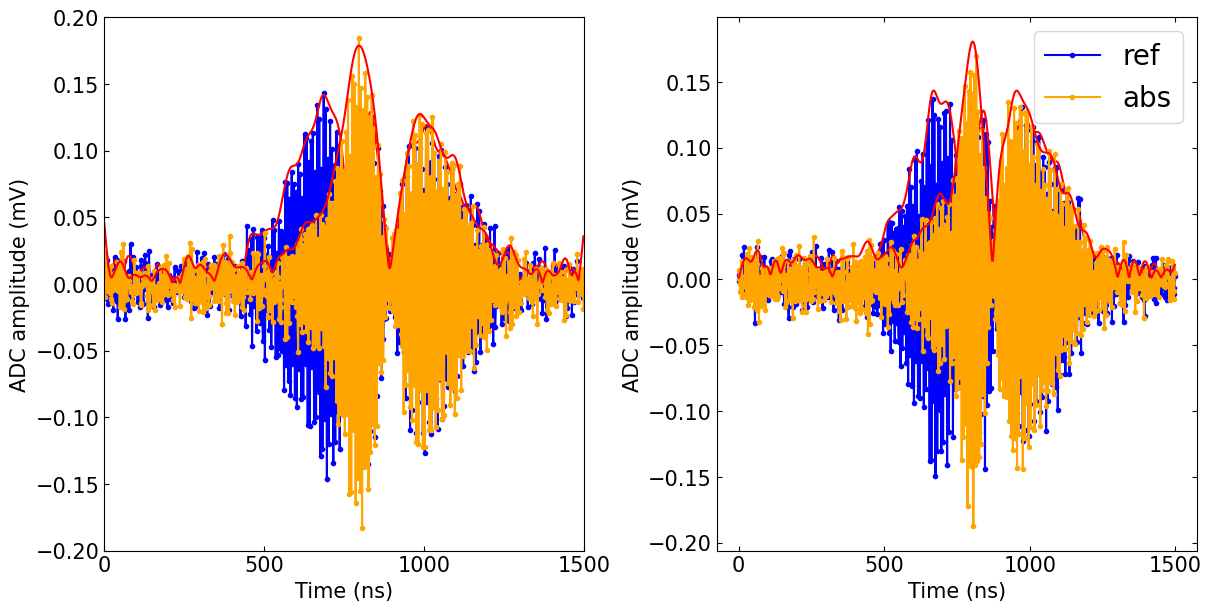

In [33]:
## waveform
ph_amp = 0
fogi_freq = 29

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d20[1][ph_amp][fogi_freq],  (d20[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d21[1][ph_amp][fogi_freq],  (d21[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d20[5][ph_amp][fogi_freq], 2))
print(np.round(d21[5][ph_amp][fogi_freq], 2))
plt.show()

85.77
-11.07


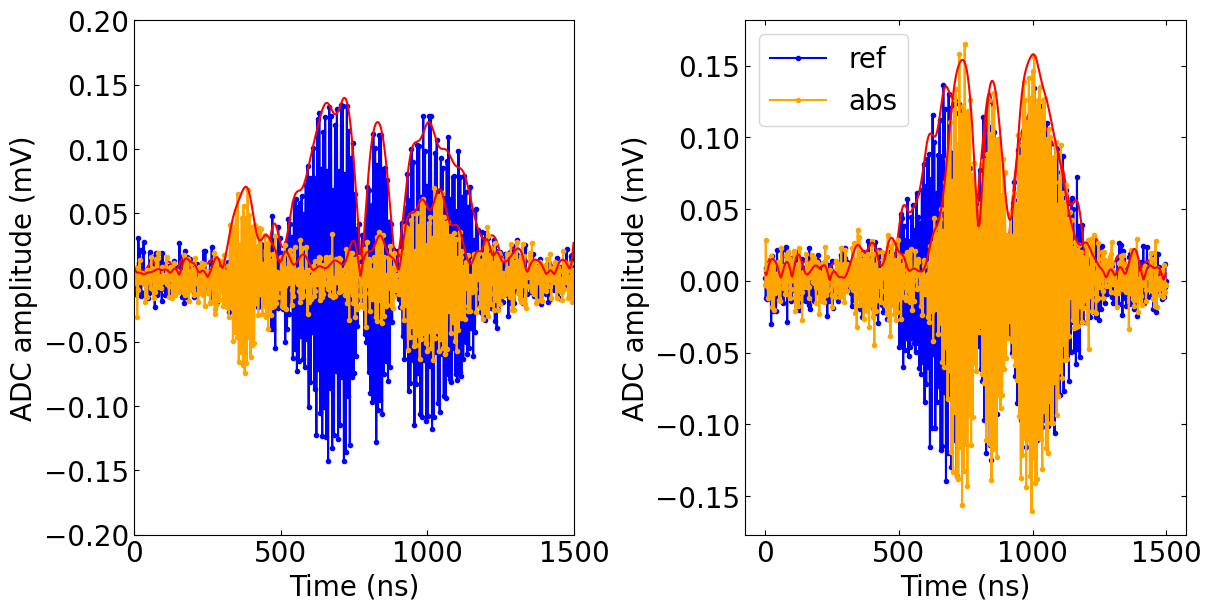

In [34]:
## waveform
ph_amp = 0
fogi_freq = 29

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d22[1][ph_amp][fogi_freq],  (d22[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d23[1][ph_amp][fogi_freq],  (d23[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d22[5][ph_amp][fogi_freq], 2))
print(np.round(d23[5][ph_amp][fogi_freq], 2))
plt.show()

phototn 3

In [35]:
ph3_fo0 = "/2024-10-14/2024-10-14T205458_22d2f9b5-75-sym_JPA_ab_fogi_timing"
ph3_fo1 = "/2024-10-14/2024-10-14T221607_78ed92b8-75-sym_JPA_ab_fogi_timing"
ph3_fo2 = "/2024-10-14/2024-10-14T233719_d138be6b-75-sym_JPA_ab_fogi_timing"
ph3_fo3 = "/2024-10-15/2024-10-15T005845_315dbb81-75-sym_JPA_ab_fogi_timing"

In [42]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo0
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d30 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time30 = d30[0][ph_amp]
ph3fo0 = d30[5][ph_amp]

In [43]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo1
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d31 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time31 = d31[0][ph_amp]
ph3fo1 = d31[5][ph_amp]

In [44]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo2
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d32 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time32 = d32[0][ph_amp]
ph3fo2 = d32[5][ph_amp]

In [37]:
## absorption rate
ph_amp = 0
###############################################
data = ph3_fo3
num_of_ph_amp = 1
num_of_fogi_timing = 51
###############################################
d33 = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, (9.5-9.35)*1e9)
time33 = d33[0][ph_amp]
ph3fo3 = d33[5][ph_amp]

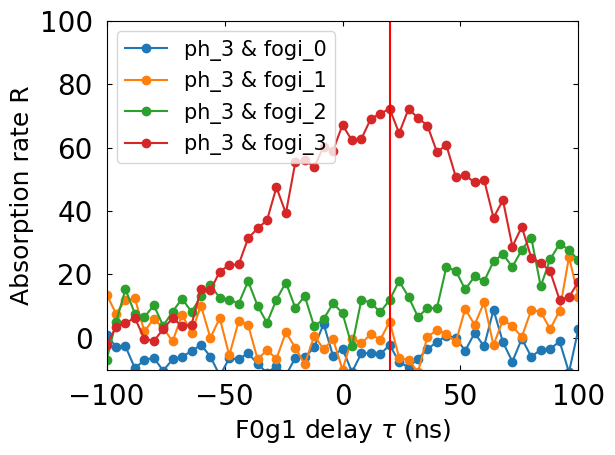

In [45]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time30, ph3fo0, "o-", label= "ph_3 & fogi_0")
plt.plot(time31, ph3fo1, "o-", label= "ph_3 & fogi_1")
plt.plot(time32, ph3fo2, "o-", label= "ph_3 & fogi_2")
plt.plot(time33, ph3fo3, "o-", label= "ph_3 & fogi_3")
plt.vlines(20, -10, 100, color="r")
plt.legend()
plt.show()

-2.22
5.16


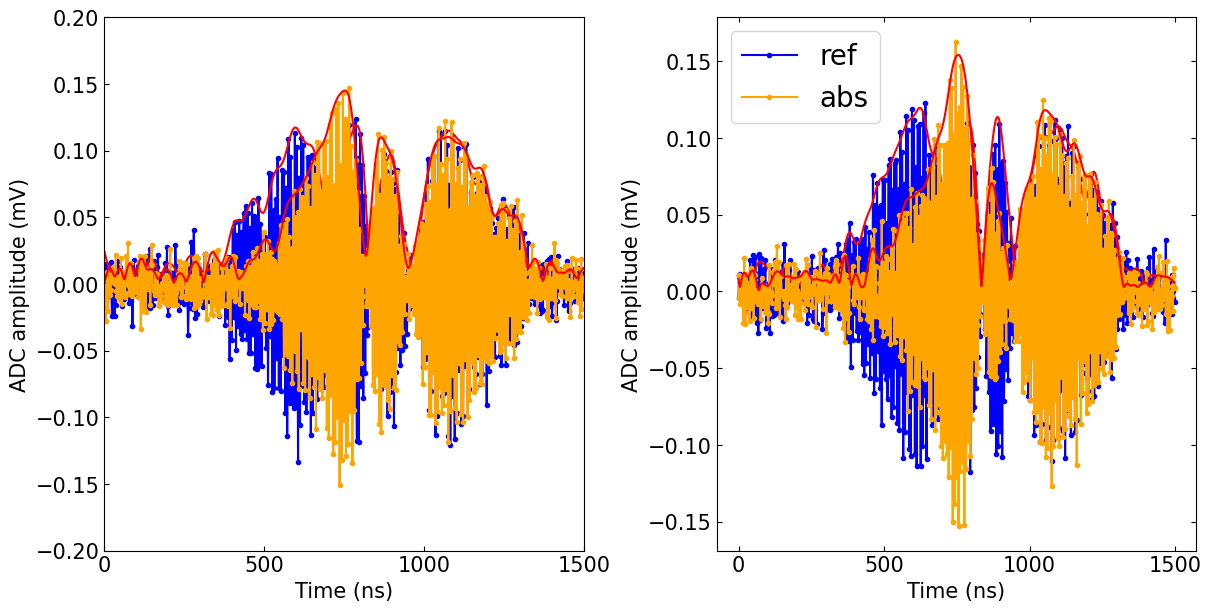

In [46]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d30[1][ph_amp][fogi_freq],  (d30[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d31[1][ph_amp][fogi_freq],  (d31[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d30[5][ph_amp][fogi_freq], 2))
print(np.round(d31[5][ph_amp][fogi_freq], 2))
plt.show()

12.04
72.31


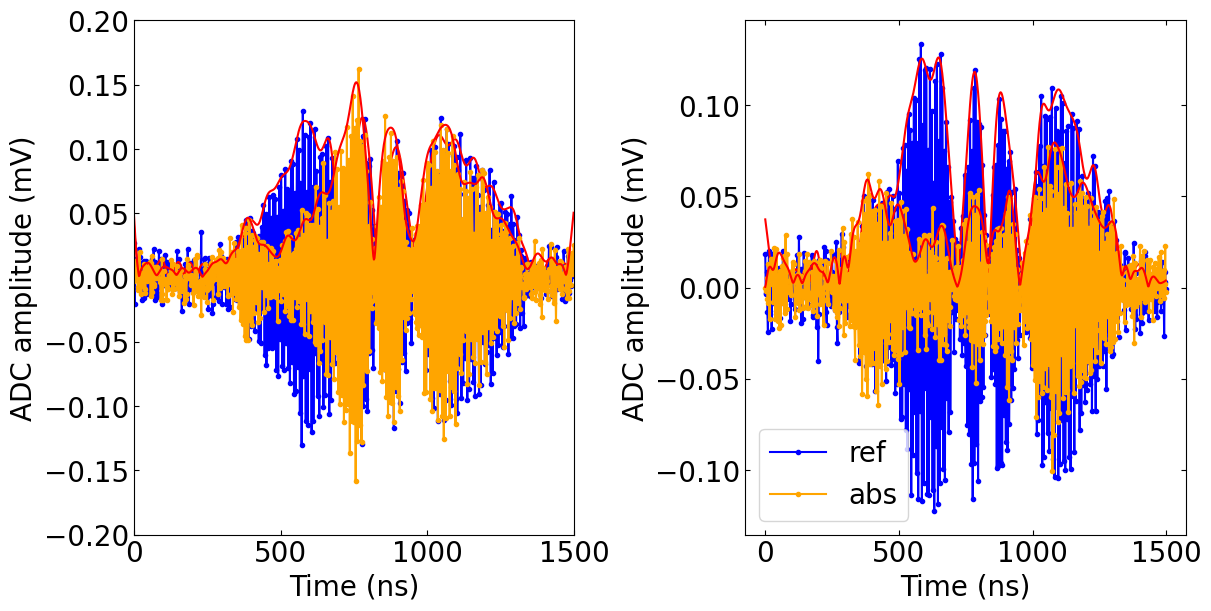

In [48]:
## waveform
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'ADC amplitude (mV)')
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[8][ph_amp][fogi_freq])*1e3, color='red')
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[0].plot(d32[1][ph_amp][fogi_freq],  (d32[7][ph_amp][fogi_freq])*1e3, color='red')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)

ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel(r'ADC amplitude (mV)')
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[3][ph_amp][fogi_freq])*1e3, '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[8][ph_amp][fogi_freq])*1e3, color='red')
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[2][ph_amp][fogi_freq])*1e3, '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax[1].plot(d33[1][ph_amp][fogi_freq],  (d33[7][ph_amp][fogi_freq])*1e3, color='red')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.2, 0.2)
ax[0].set_xlim(0, 1500)
plt.legend()
print(np.round(d32[5][ph_amp][fogi_freq], 2))
print(np.round(d33[5][ph_amp][fogi_freq], 2))
plt.show()

## analysis

In [49]:
i_n0 = 25
i_n1 = 25#28
i_n2 = 25#28
i_n3 = 25#29
data = np.array([[ph3fo0[i_n3], ph3fo1[i_n3], ph3fo2[i_n3], ph3fo3[i_n3]],
        [ph2fo0[i_n2], ph2fo1[i_n2], ph2fo2[i_n2], ph2fo3[i_n2]],
        [ph1fo0[i_n1], ph1fo1[i_n1], ph1fo2[i_n1], ph1fo3[i_n1]],
        [ph0fo0[i_n0], ph0fo1[i_n0], ph0fo2[i_n0], ph0fo3[i_n0]]])

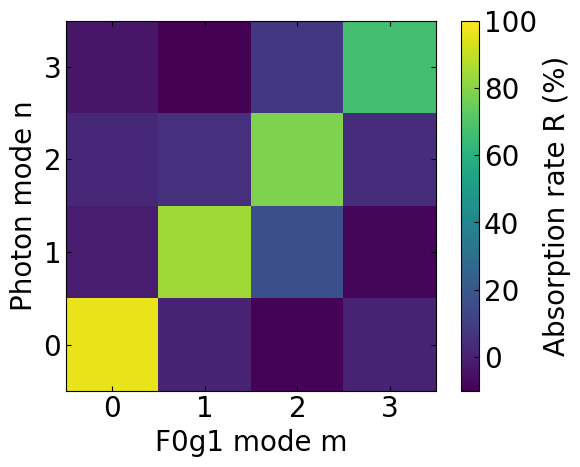

In [50]:
# secax_y = ax.secondary_yaxis((0, 3),
#                                  functions=(lambda y: y*1 + 0, lambda y: (y - 0) / 1))
extent = (0, 3, 0, 3)

plt.imshow(data, extent=extent, filternorm=False, vmax=100)
colorbar = plt.colorbar(label="Absorption rate R (%)")
colorbar.set_ticks([0, 20, 40, 60, 80, 100])
plt.ylabel("Photon mode n")
plt.xlabel("F0g1 mode m")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))

# for i in range(num_y_ticks):
#     for j in range(num_x_ticks):
#         plt.text(x_ticks[i], 3-y_ticks[j], f"{int(data[j, i])}", ha='center', va='center', color="red")


plt.show()

In [51]:
def sech_0(time, const):
    return (const/2)**0.5/np.cosh(const*time)

def sech_1(time, const):
    return (6*const**3/(np.pi**2))**0.5/np.cosh(const*time)*time

def sech_2(time, const):
    return (45*(2*const)**5/64/(np.pi**4))**0.5/np.cosh(const*time)*(time**2-(np.pi/2/const)**2/3)

def sech_3(time, const):
    return (175*(2*const)**7)**0.5/24/(np.pi**3)/np.cosh(const*time)*(time**3-(7*time*(np.pi/(2*const))**2/5))

In [52]:
const = 2.5e-3 * 2 * np.pi

def sech_00(time, tau):
    return sech_0(time, const)*sech_0(time+tau, const)
def sech_01(time, tau):
    return sech_0(time, const)*sech_1(time+tau, const)
def sech_11(time, tau):
    return sech_1(time, const)*sech_1(time+tau, const)

def sech_02(time, tau):
    return sech_0(time, const)*sech_2(time+tau, const)
def sech_12(time, tau):
    return sech_1(time, const)*sech_2(time+tau, const)
def sech_22(time, tau):
    return sech_2(time, const)*sech_2(time+tau, const)

def sech_03(time, tau):
    return sech_0(time, const)*sech_3(time+tau, const)
def sech_13(time, tau):
    return sech_1(time, const)*sech_3(time+tau, const)
def sech_23(time, tau):
    return sech_2(time, const)*sech_3(time+tau, const)
def sech_33(time, tau):
    return sech_3(time, const)*sech_3(time+tau, const)

In [53]:
def fit_waveform(time, data, x0=[2e-3,400], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

In [54]:
result_dict = dict(
    data_ph0 = dict(target_freq=9.35, date="2024-10-13", acquire_time="233331"),
    data_ph1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234021"),
    data_ph2 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234709"),
    data_ph3 = dict(target_freq=9.35, date="2024-10-13", acquire_time="235358"),
)

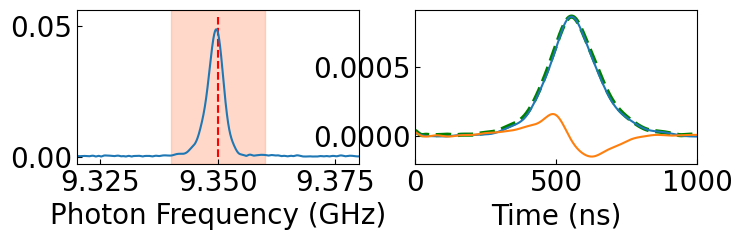

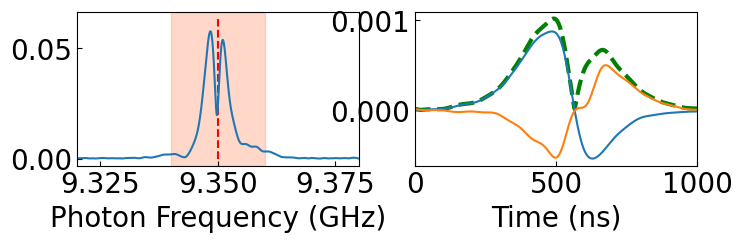

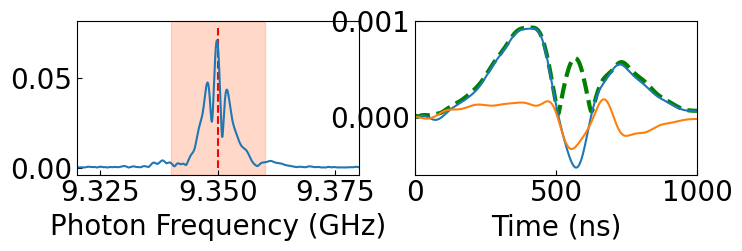

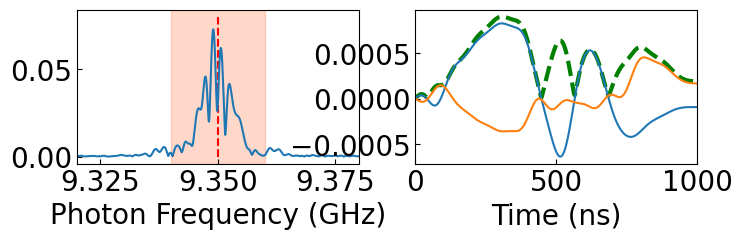

In [55]:
from datataking import search_datadict_miyamura
readout_lo_freq = 9.5
passing_band = 0.01
duration=1000
cd = "CDY168"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

signals = []
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    signals.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)

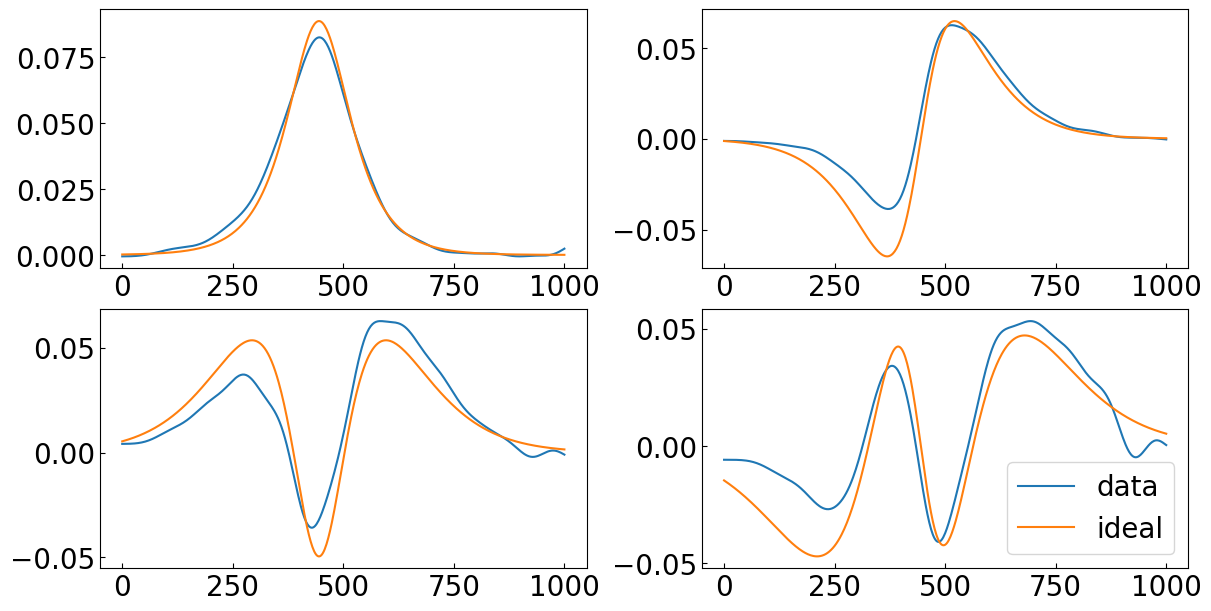

In [56]:
signal_ph0, signal_ph1, signal_ph2, signal_ph3 = signals[0][::-1], signals[1][::-1], signals[2][::-1], signals[3][::-1]
data_t = np.linspace(0, 1000, 501)
def signal_cohe0(tau):
     return sech_0(data_t+tau-500, const)
def signal_cohe1(tau):
     return sech_1(data_t+tau-500, const)
def signal_cohe2(tau):
     return sech_2(data_t+tau-500, const)
def signal_cohe3(tau):
     return sech_3(data_t+tau-500, const)

fig, ax = plt.subplots(2,2,figsize=(12,6),constrained_layout=True)
tau = 55
ax[0][0].plot(data_t, signal_ph0.real, label ='data')
ax[0][0].plot(data_t, signal_cohe0(tau), label ='ideal')

ax[0][1].plot(data_t, signal_ph1.real, label ='data')
ax[0][1].plot(data_t, signal_cohe1(tau), label ='ideal')

ax[1][0].plot(data_t, signal_ph2.real, label ='data')
ax[1][0].plot(data_t, signal_cohe2(tau), label ='ideal')

ax[1][1].plot(data_t, signal_ph3.real, label ='data')
ax[1][1].plot(data_t, signal_cohe3( tau), label ='ideal')
plt.legend()

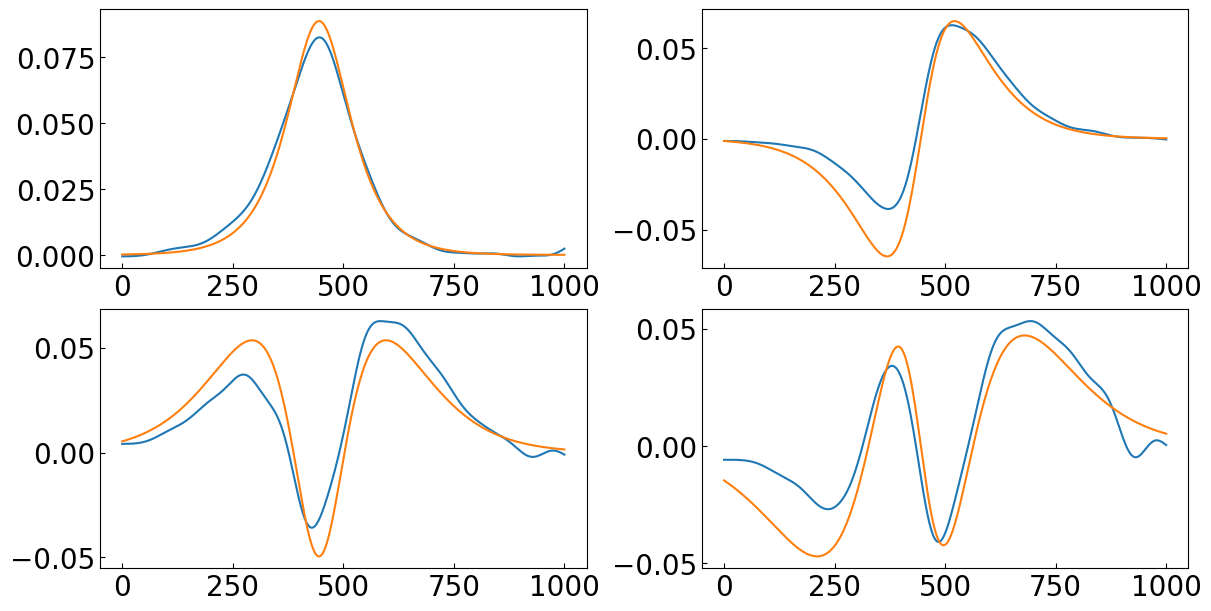

In [57]:
fig, ax = plt.subplots(2,2,figsize=(12,6),constrained_layout=True)
tau = 55
ax[0][0].plot(data_t, signal_ph0.real, label ='data')
ax[0][0].plot(data_t, signal_cohe0(tau), label ='ideal')

ax[0][1].plot(data_t, signal_ph1.real, label ='data')
ax[0][1].plot(data_t, signal_cohe1(tau), label ='ideal')

ax[1][0].plot(data_t, signal_ph2.real, label ='data')
ax[1][0].plot(data_t, signal_cohe2(tau), label ='ideal')

ax[1][1].plot(data_t, signal_ph3.real, label ='data')
ax[1][1].plot(data_t, signal_cohe3( tau), label ='ideal')

In [59]:
from scipy.integrate import quad

def overlap(func, taus, time):
    ys = []
    for t in taus:
        def new_func(t_value):
            return func(time=t_value, tau=t)
        integral_value = abs(quad(new_func, time[0], time[-1])[0])**2
        ys.append(integral_value)
    return np.array(ys) * 100

In [66]:
def overlap_exp(data_func, ideal_func, taus, time):
    ys = []
    for t in taus:
        new_func = data_func.conj() * ideal_func(tau=t)
        y = np.abs((np.sum(new_func) * 2))**2
        ys.append(y)
    return np.array(ys)*100

In [67]:
taus = np.linspace(-100, 100, 201)

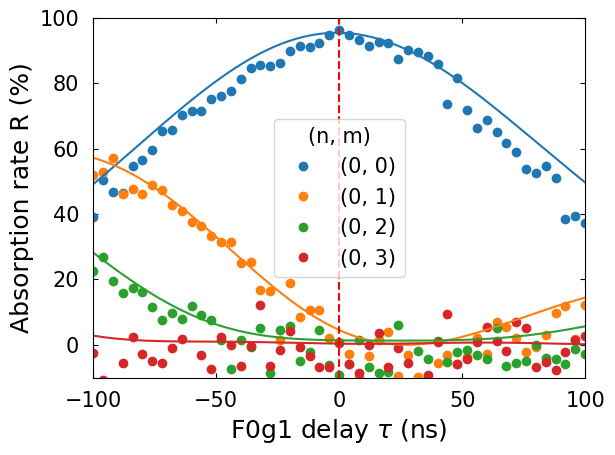

In [69]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R (%)', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time00, ph0fo0, "o", label= "(0, 0)")
plt.plot(time01, ph0fo1, "o", label= "(0, 1)")
plt.plot(time02, ph0fo2, "o", label= "(0, 2)")
plt.plot(time03, ph0fo3, "o", label= "(0, 3)")
# plt.plot(taus, overlap(sech_00, taus-0, time), "--", color="b")
# plt.plot(taus, overlap(sech_01, taus-12, time), "--", color="orange")
# plt.plot(taus, overlap(sech_02, taus-16, time), "--", color="g")
# plt.plot(taus, overlap(sech_03, taus-20, time), "--", color="r")

plt.plot(taus, overlap_exp(signal_ph0, signal_cohe0, taus+60, data_t), color="tab:blue")
plt.plot(taus, overlap_exp(signal_ph1, signal_cohe0, taus+60, data_t), color="tab:orange")
plt.plot(taus, overlap_exp(signal_ph2, signal_cohe0, taus+60, data_t), color="tab:green")
plt.plot(taus, overlap_exp(signal_ph3, signal_cohe0, taus+60, data_t), color="tab:red")
plt.legend(title="(n, m)")
ax1.vlines(0, -10, 100, color="r", ls="--")
plt.show()

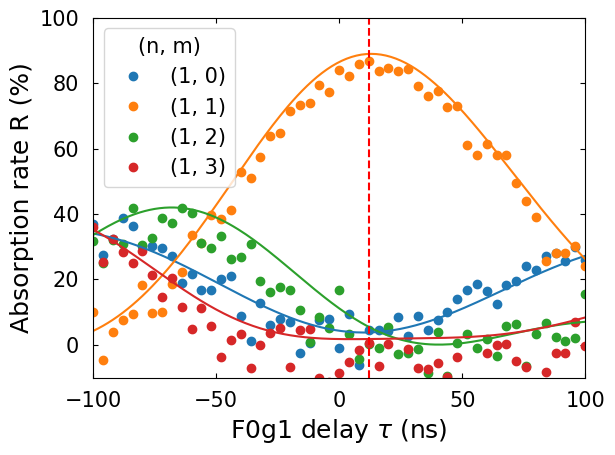

In [55]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R (%)', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time10, ph1fo0, "o", label= "(1, 0)")
plt.plot(time11, ph1fo1, "o", label= "(1, 1)")
plt.plot(time12, ph1fo2, "o", label= "(1, 2)")
plt.plot(time13, ph1fo3, "o", label= "(1, 3)")
# plt.plot(taus, overlap(sech_01, taus, time), "--", color="b")
# plt.plot(taus, overlap(sech_11, taus-12, time), "--", color="orange")
# plt.plot(taus, overlap(sech_12, taus-16, time), "--", color="g")
# plt.plot(taus, overlap(sech_13, taus-20, time), "--", color="r")
plt.plot(taus, overlap_exp(signal_ph0, signal_cohe1, taus+51, data_t), color="tab:blue")
plt.plot(taus, overlap_exp(signal_ph1, signal_cohe1, taus+51, data_t), color="tab:orange")
plt.plot(taus, overlap_exp(signal_ph2, signal_cohe1, taus+51, data_t), color="tab:green")
plt.plot(taus, overlap_exp(signal_ph3, signal_cohe1, taus+51, data_t), color="tab:red")
plt.legend(title="(n, m)")
ax1.vlines(12, -10, 100, color="r", ls="--")
plt.show()

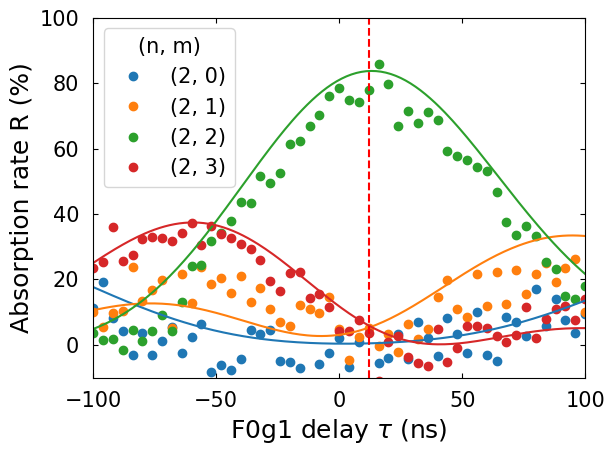

In [56]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R (%)', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time20, ph2fo0, "o", label= "(2, 0)")
plt.plot(time21, ph2fo1, "o", label= "(2, 1)")
plt.plot(time22, ph2fo2, "o", label= "(2, 2)")
plt.plot(time23, ph2fo3, "o", label= "(2, 3)")
# plt.plot(taus, overlap(sech_02, taus, time), "--", color="b")
# plt.plot(taus, overlap(sech_12, taus-12, time), "--", color="orange")
# plt.plot(taus, overlap(sech_22, taus-16, time), "--", color="g")
# plt.plot(taus, overlap(sech_23, taus-20, time), "--", color="r")
plt.plot(taus, overlap_exp(signal_ph0, signal_cohe2, taus+51, data_t), color="tab:blue")
plt.plot(taus, overlap_exp(signal_ph1, signal_cohe2, taus+51, data_t), color="tab:orange")
plt.plot(taus, overlap_exp(signal_ph2, signal_cohe2, taus+51, data_t), color="tab:green")
plt.plot(taus, overlap_exp(signal_ph3, signal_cohe2, taus+51, data_t), color="tab:red")
plt.legend(title="(n, m)")
ax1.vlines(12, -10, 100, color="r", ls="--")
plt.show()

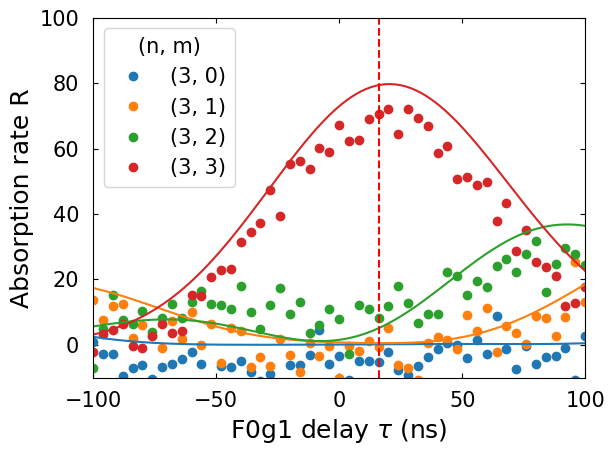

In [57]:
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-100, 100)
plt.tight_layout()
plt.plot(time30, ph3fo0, "o", label= "(3, 0)")
plt.plot(time31, ph3fo1, "o", label= "(3, 1)")
plt.plot(time32, ph3fo2, "o", label= "(3, 2)")
plt.plot(time33, ph3fo3, "o", label= "(3, 3)")
# plt.plot(taus, overlap(sech_03, taus, time), "--", color="b")
# plt.plot(taus, overlap(sech_13, taus-12, time), "--", color="orange")
# plt.plot(taus, overlap(sech_23, taus-16, time), "--", color="g")
# plt.plot(taus, overlap(sech_33, taus-20, time), "--", color="r")
plt.plot(taus, overlap_exp(signal_ph0, signal_cohe3, taus+45, data_t), color="tab:blue")
plt.plot(taus, overlap_exp(signal_ph1, signal_cohe3, taus+45, data_t), color="tab:orange")
plt.plot(taus, overlap_exp(signal_ph2, signal_cohe3, taus+45, data_t), color="tab:green")
plt.plot(taus, overlap_exp(signal_ph3, signal_cohe3, taus+45, data_t), color="tab:red")
plt.legend(title="(n, m)")
ax1.vlines(16, -10, 100, color="r", ls="--")
plt.show()